In [31]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

from hmmlearn.hmm import CategoricalHMM
from sklearn.model_selection import train_test_split

### data

In [3]:
def load_vote_file(file_path):

    filename = os.path.basename(file_path)

    # votes_house_119_1_35.csv
    match = re.search(
        r"votes_house_(\d+)_(\d+)_(\d+)\.csv$",
        filename
    )

    if match is None:
        raise ValueError(f"Could not parse filename: {filename}")

    term = int(match.group(1))
    session = int(match.group(2))
    roll_call = int(match.group(3))

    df = pd.read_csv(
        file_path,
        skiprows=5,
        header=None,
        usecols=[0, 1, 2, 3],
        names=[
            "Representative",
            "Party",
            "State",
            "Vote"
        ]
    )

    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()

    vote_map = {
        "Yea": 1,
        "Aye": 1,
        "No": 0,
        "Nay": 0,
        "Present": 2,
        "Not Voting": 2
    }

    df["Vote_Code"] = df["Vote"].map(vote_map)

    df = df.dropna(subset=["Vote_Code"])

    df["Vote_Code"] = df["Vote_Code"].astype(int)

    df["Term"] = term
    df["Session"] = session
    df["Roll_Call"] = roll_call

    return df

In [4]:
base_folder = "data/raw"

files = glob.glob(
    os.path.join(base_folder, "**", "*.csv"),
    recursive=True
)

print("Files found:", len(files))

all_votes = pd.concat(
    [load_vote_file(file) for file in files],
    ignore_index=True
)

vote_order = (
    all_votes[
        ["Term", "Session", "Roll_Call"]
    ]
    .drop_duplicates()
    .sort_values(
        ["Term", "Session", "Roll_Call"]
    )
    .reset_index(drop=True)
)

vote_order["Time_Index"] = np.arange(
    len(vote_order)
)

all_votes = all_votes.merge(
    vote_order,
    on=["Term", "Session", "Roll_Call"],
    how="left"
)


print("\nFirst 20 votes chronologically:")
display(vote_order.head(20))

print("\nLast 20 votes chronologically:")
display(vote_order.tail(20))

Files found: 406

First 20 votes chronologically:


,Term,Session,Roll_Call,Time_Index
0,116,1,651,0
1,116,1,652,1
2,116,1,653,2
3,116,1,654,3
4,116,1,655,4
5,116,1,656,5
6,116,1,657,6
7,116,1,658,7
8,116,1,659,8
9,116,1,660,9



Last 20 votes chronologically:


,Term,Session,Roll_Call,Time_Index
386,119,2,172,386
387,119,2,173,387
388,119,2,174,388
389,119,2,175,389
390,119,2,176,390
391,119,2,177,391
392,119,2,178,392
393,119,2,179,393
394,119,2,180,394
395,119,2,181,395


In [5]:
vote_matrix = all_votes.pivot_table(
    index="Representative",
    columns="Time_Index",
    values="Vote_Code",
    aggfunc="first"
)

rep_info = (
    all_votes
    .groupby("Representative")[["Party", "State"]]
    .first()
)

# Ensure matching indices
common_reps = vote_matrix.index.intersection(
    rep_info.index
)

vote_matrix = vote_matrix.loc[common_reps]
rep_info = rep_info.loc[common_reps]

# Count representatives before filtering
original_reps = len(vote_matrix)

# Keep only representatives with no missing votes
complete_vote_matrix = vote_matrix.dropna()

remaining_reps = len(complete_vote_matrix)

print(f"Representatives before filtering: {original_reps}")
print(f"Representatives after filtering:  {remaining_reps}")
print(f"Removed: {original_reps - remaining_reps}")

vote_matrix = complete_vote_matrix.astype(int)

rep_info = rep_info.loc[vote_matrix.index]

print("\nVote matrix shape:")
print(vote_matrix.shape)

display(vote_matrix.head())
display(rep_info.head())

Representatives before filtering: 691
Representatives after filtering:  220
Removed: 471

Vote matrix shape:
(220, 406)


Time_Index,0,1,2,3,4,5,6,7,8,9,...,396,397,398,399,400,401,402,403,404,405
Representative,,,,,,,,,,,,,,,,,,,,,
"Adams, Alma S. [D-NC]",1,1,0,1,1,1,1,1,1,1,...,1,1,0,0,0,1,0,1,0,0
"Aderholt, Robert B. [R-AL]",0,0,1,0,2,2,2,2,2,2,...,1,0,1,1,1,0,1,0,1,1
"Aguilar, Pete [D-CA]",1,1,0,1,1,1,1,1,1,1,...,1,1,0,0,0,1,0,1,0,0
"Allen, Rick W. [R-GA]",0,0,1,0,1,1,0,0,1,0,...,1,0,1,1,1,0,1,0,1,1
"Amodei, Mark E. [R-NV]",0,0,1,0,1,1,0,0,1,0,...,1,0,1,1,1,0,1,0,1,1


,Party,State
Representative,,
"Adams, Alma S. [D-NC]",Democratic,North Carolina
"Aderholt, Robert B. [R-AL]",Republican,Alabama
"Aguilar, Pete [D-CA]",Democratic,California
"Allen, Rick W. [R-GA]",Republican,Georgia
"Amodei, Mark E. [R-NV]",Republican,Nevada


In [15]:
X = vote_matrix.to_numpy().reshape(-1, 1)

lengths = [
    vote_matrix.shape[1]
] * vote_matrix.shape[0]

print("HMM Input Summary")
print("X shape:", X.shape)
print("Representatives:", vote_matrix.shape[0])
print("Votes per representative:", vote_matrix.shape[1])
print("Lengths sum:", sum(lengths))

assert sum(lengths) == len(X)

HMM Input Summary
X shape: (89320, 1)
Representatives: 220
Votes per representative: 406
Lengths sum: 89320


### experiments

,Hidden States,Log Likelihood,AIC-like Score
0,2,-66378.935574,132771.871147
1,3,-60256.747516,120541.495033
2,4,-59799.323921,119644.647842
3,5,-56005.202274,112078.404547
4,6,-55974.144007,112042.288013
5,7,-55946.830244,112017.660489
6,8,-55298.965854,110755.931709
7,9,-55363.879090,110923.758179
8,10,-55053.505904,110345.011809


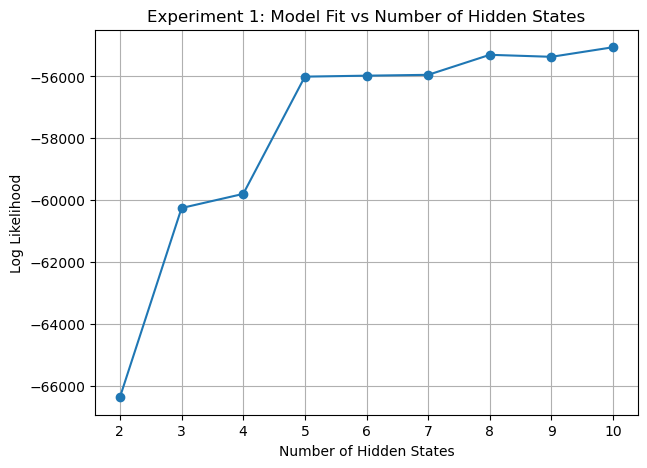

In [17]:
results = []

for k in range(2,11):
    model = CategoricalHMM(
        n_components=k,
        n_iter=200,
        random_state=42,
        tol=1e-4
    )

    model.fit(X, lengths)
    log_likelihood = model.score(X, lengths)

    num_obs = 3

    num_params = (
        k * (k - 1) +      # transitions
        k * (num_obs - 1) + # emissions
        (k - 1)             # initial probs
    )
    
    aic = -2 * log_likelihood + 2 * num_params

    results.append({
        "Hidden States": k,
        "Log Likelihood": log_likelihood,
        "AIC-like Score": aic
    })

results_df = pd.DataFrame(results)
display(results_df)

plt.figure(figsize=(7, 5))
plt.plot(results_df["Hidden States"], results_df["Log Likelihood"], marker="o")
plt.xlabel("Number of Hidden States")
plt.ylabel("Log Likelihood")
plt.title("Experiment 1: Model Fit vs Number of Hidden States")
plt.grid(True)
plt.show()

Party
Democratic    122
Republican     98
Name: count, dtype: int64

Train reps: 165
Test reps: 55
Train votes: 66990
Test votes: 22330


,Hidden States,Train Log Likelihood,Test Log Likelihood,Train LL per Vote,Test LL per Vote
0,2,-49969.551629,-16410.443974,-0.745926,-0.734906
1,3,-45314.869683,-14946.382408,-0.676442,-0.669341
2,4,-44924.702893,-14870.650916,-0.670618,-0.665949
3,5,-42053.894258,-13954.535762,-0.627764,-0.624923
4,6,-41985.951109,-13935.795170,-0.626750,-0.624084
5,7,-42010.102379,-13942.494942,-0.627110,-0.624384
6,8,-41517.580820,-13808.878321,-0.619758,-0.618400
7,9,-41565.205202,-13818.032711,-0.620469,-0.618810
8,10,-41338.727436,-13718.191956,-0.617088,-0.614339


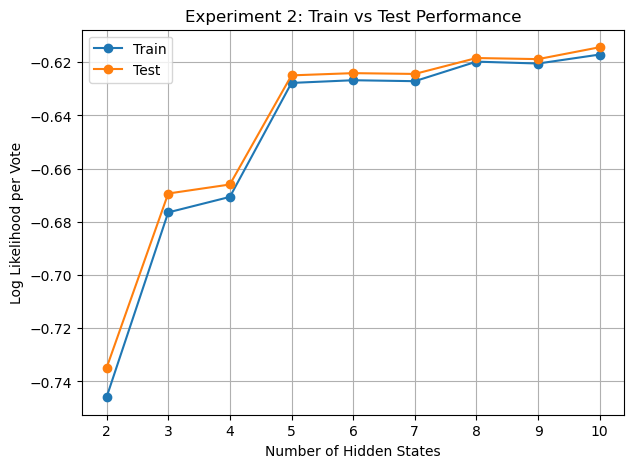

In [19]:
from sklearn.model_selection import train_test_split

party_counts = rep_info.loc[vote_matrix.index, "Party"].value_counts()
display(party_counts)

parties = rep_info.loc[vote_matrix.index, "Party"]

if parties.value_counts().min() >= 2:
    train_reps, test_reps = train_test_split(
        vote_matrix.index,
        test_size=0.25,
        random_state=42,
        stratify=parties
    )
else:
    train_reps, test_reps = train_test_split(
        vote_matrix.index,
        test_size=0.25,
        random_state=42
    )

train_matrix = vote_matrix.loc[train_reps]
test_matrix = vote_matrix.loc[test_reps]

X_train = train_matrix.to_numpy().reshape(-1, 1)
lengths_train = [train_matrix.shape[1]] * train_matrix.shape[0]

X_test = test_matrix.to_numpy().reshape(-1, 1)
lengths_test = [test_matrix.shape[1]] * test_matrix.shape[0]

print("Train reps:", train_matrix.shape[0])
print("Test reps:", test_matrix.shape[0])
print("Train votes:", len(X_train))
print("Test votes:", len(X_test))

test_results = []

for k in range(2,11):
    model = CategoricalHMM(
        n_components=k,
        n_iter=200,
        random_state=42,
        tol=1e-4,
        init_params="ste"
    )

    model.fit(X_train, lengths_train)

    train_ll = model.score(X_train, lengths_train)
    test_ll = model.score(X_test, lengths_test)

    test_results.append({
        "Hidden States": k,
        "Train Log Likelihood": train_ll,
        "Test Log Likelihood": test_ll,
        "Train LL per Vote": train_ll / len(X_train),
        "Test LL per Vote": test_ll / len(X_test)
    })

test_results_df = pd.DataFrame(test_results)
display(test_results_df)

plt.figure(figsize=(7, 5))
plt.plot(
    test_results_df["Hidden States"],
    test_results_df["Train LL per Vote"],
    marker="o",
    label="Train"
)
plt.plot(
    test_results_df["Hidden States"],
    test_results_df["Test LL per Vote"],
    marker="o",
    label="Test"
)

plt.xlabel("Number of Hidden States")
plt.ylabel("Log Likelihood per Vote")
plt.title("Experiment 2: Train vs Test Performance")
plt.legend()
plt.grid(True)
plt.show()

Training votes per representative: 304
Testing votes per representative: 102


,Hidden States,Train Log Likelihood,Test Log Likelihood,Train LL per Vote,Test LL per Vote
0,2,-42200.670970,-18298.026173,-0.630991,-0.815420
1,3,-42152.131083,-18240.116819,-0.630265,-0.812839
2,4,-42029.866360,-18016.995988,-0.628437,-0.802896
3,5,-39304.632146,-16856.945340,-0.587689,-0.751201
4,6,-38966.886063,-17005.990120,-0.582639,-0.757843
5,7,-39278.528303,-16887.374003,-0.587299,-0.752557
6,8,-38820.790810,-16919.914744,-0.580454,-0.754007
7,9,-39013.743535,-16872.999601,-0.583339,-0.751916
8,10,-38588.883701,-17162.718763,-0.576987,-0.764827


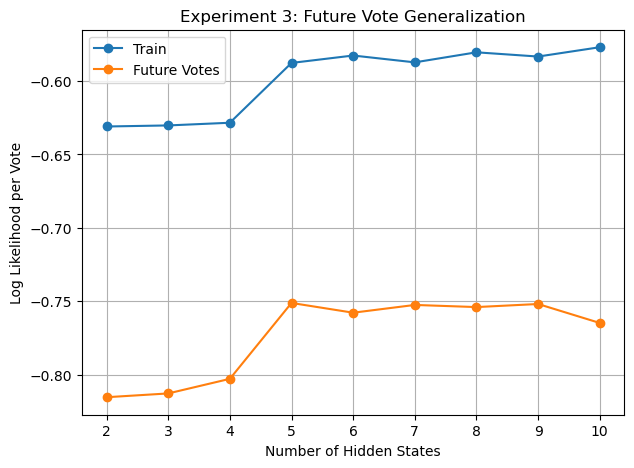

In [21]:
time_split = int(vote_matrix.shape[1] * 0.75)

train_matrix = vote_matrix.iloc[:, :time_split]
test_matrix = vote_matrix.iloc[:, time_split:]

print("Training votes per representative:", train_matrix.shape[1])
print("Testing votes per representative:", test_matrix.shape[1])

X_train = train_matrix.to_numpy().reshape(-1, 1)
lengths_train = [train_matrix.shape[1]] * train_matrix.shape[0]

X_test = test_matrix.to_numpy().reshape(-1, 1)
lengths_test = [test_matrix.shape[1]] * test_matrix.shape[0]

future_results = []

for k in range(2,11):

    model = CategoricalHMM(
        n_components=k,
        n_iter=200,
        random_state=42,
        tol=1e-4
    )

    model.fit(X_train, lengths_train)

    train_ll = model.score(X_train, lengths_train)
    test_ll = model.score(X_test, lengths_test)

    future_results.append({
        "Hidden States": k,
        "Train Log Likelihood": train_ll,
        "Test Log Likelihood": test_ll,
        "Train LL per Vote": train_ll / len(X_train),
        "Test LL per Vote": test_ll / len(X_test)
    })

future_results_df = pd.DataFrame(future_results)

display(future_results_df)

plt.figure(figsize=(7, 5))

plt.plot(
    future_results_df["Hidden States"],
    future_results_df["Train LL per Vote"],
    marker="o",
    label="Train"
)

plt.plot(
    future_results_df["Hidden States"],
    future_results_df["Test LL per Vote"],
    marker="o",
    label="Future Votes"
)

plt.xlabel("Number of Hidden States")
plt.ylabel("Log Likelihood per Vote")
plt.title("Experiment 3: Future Vote Generalization")
plt.legend()
plt.grid(True)
plt.show()

### analysis

In [35]:
best_k = 5

best_model = CategoricalHMM(
    n_components=best_k,
    n_iter=200,
    random_state=42,
    tol=1e-4
)

best_model.fit(X, lengths)

CategoricalHMM(n_components=5, n_features=3, n_iter=200,
               random_state=RandomState(MT19937) at 0x152654740, tol=0.0001)

In [39]:
best_model.emissionprob_

array([[5.65053664e-01, 4.14775481e-01, 2.01708557e-02],
       [3.34945801e-01, 6.64827052e-01, 2.27147526e-04],
       [1.03790928e-01, 8.89407755e-01, 6.80131730e-03],
       [8.82060463e-07, 6.81445686e-04, 9.99317672e-01],
       [5.86345977e-01, 4.07525116e-01, 6.12890713e-03]])

,Nay,Yea,Present
0,5.650537e-01,0.414775,0.020171
1,3.349458e-01,0.664827,0.000227
2,1.037909e-01,0.889408,0.006801
3,8.820605e-07,0.000681,0.999318
4,5.863460e-01,0.407525,0.006129


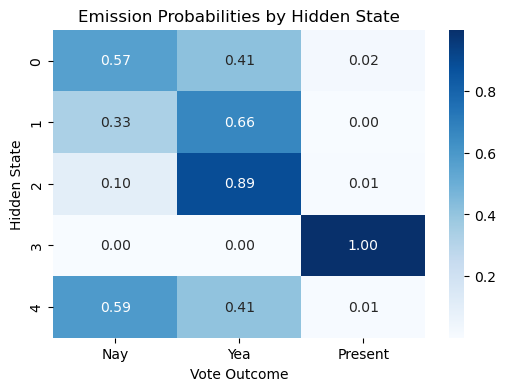

In [37]:
emissions = pd.DataFrame(
    best_model.emissionprob_,
    columns=["Nay", "Yea", "Present"]
)

display(emissions)

plt.figure(figsize=(6,4))
sns.heatmap(
    emissions,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.xlabel("Vote Outcome")
plt.ylabel("Hidden State")
plt.title("Emission Probabilities by Hidden State")
plt.show()

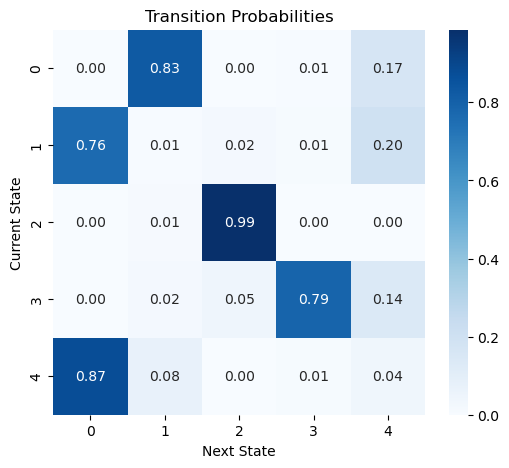

In [41]:
transitions = pd.DataFrame(
    best_model.transmat_
)

plt.figure(figsize=(6,5))

sns.heatmap(
    transitions,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.xlabel("Next State")
plt.ylabel("Current State")
plt.title("Transition Probabilities")
plt.show()